<a href="https://colab.research.google.com/github/himashi27/neural-network-/blob/main/project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Create an ANN model using the structured dataset and a CNN for the unstructured dataset. The dataset will be on the Kaggle website.**

### 1. Data Loading and Preprocessing

We'll start by loading your structured dataset and performing basic preprocessing.

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Load your dataset ---
# Replace '/content/AI_Impact_Student_Life_2026.csv' with the actual path to your structured dataset
try:
    df = pd.read_csv('/content/AI_Impact_Student_Life_2026.csv')
    print("Dataset loaded successfully. First 5 rows:")
    display(df.head())
except FileNotFoundError:
    print("Error: '/content/AI_Impact_Student_Life_2026.csv' not found. Please upload your dataset or provide the correct path.")
    print("You can upload a file by clicking the folder icon on the left panel, then the upload icon.")
    # Exit or handle the error appropriately
    exit()

# --- Define features (X) and target (y) ---
# Replace 'target_column' with the name of your target variable
# All other columns will be considered features.
# If you have specific feature columns, list them explicitly.

# Example for a classification problem:
target_column = 'GPA_Post_AI' # Changed target from 'Student_ID' to 'GPA_Post_AI' for regression

if target_column not in df.columns:
    print(f"Error: Target column '{target_column}' not found in the dataset. Please adjust the target_column variable.")
    exit()

X = df.drop(columns=[target_column, 'Student_ID']) # Drop 'Student_ID' as it's an identifier
y = df[target_column]

# Convert categorical features to numerical using one-hot encoding if needed
X = pd.get_dummies(X, drop_first=True)

# --- Split data into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Scale numerical features ---
# It's important to scale features for ANNs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nData split into training ({X_train_scaled.shape[0]} samples) and testing ({X_test_scaled.shape[0]} samples).")
print(f"Features scaled successfully. Number of features: {X_train_scaled.shape[1]}")

Dataset loaded successfully. First 5 rows:


,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9



Data split into training (1200 samples) and testing (300 samples).
Features scaled successfully. Number of features: 20


### 2. Build the ANN Model

Now, we'll define a simple Artificial Neural Network using TensorFlow's Keras API.

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Clear any old TensorFlow graph from memory
tf.keras.backend.clear_session()

# Determine the number of input features
input_dim = X_train_scaled.shape[1]

# Check if it's a classification or regression problem
# This is a simple heuristic; you might need to adjust based on your `y` data type
is_classification = len(y.unique()) < 20 and y.dtype in ['int64', 'object', 'bool'] # Heuristic: if few unique values and integer/bool, assume classification

# --- Define the ANN model ---
model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)), # Input layer
    Dense(32, activation='relu'),                          # Hidden layer 1
    Dense(16, activation='relu')                           # Hidden layer 2
])

if is_classification:
    # For binary classification (two classes), use sigmoid activation and binary_crossentropy loss
    if len(y.unique()) == 2:
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        print("Model configured for Binary Classification.")
    # For multi-class classification, use softmax activation and categorical_crossentropy loss
    else:
        num_classes = len(y.unique())
        model.add(Dense(num_classes, activation='softmax'))
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        print(f"Model configured for Multi-class Classification ({num_classes} classes).")
else:
    # For regression, use a linear activation (or no activation) for the output layer and mean_squared_error loss
    model.add(Dense(1)) # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    print("Model configured for Regression.")

model.summary()

Model configured for Regression.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Train the ANN Model

Now, let's train the model using your scaled training data.

In [17]:
# --- Train the model ---
# Ensure y_train and y_test are numpy arrays of float type for Keras compatibility
y_train_np = y_train.values.astype('float32')
y_test_np = y_test.values.astype('float32')

# Ensure X_train_scaled and X_test_scaled are float32, common for TF
X_train_scaled_tf = X_train_scaled.astype('float32')
X_test_scaled_tf = X_test_scaled.astype('float32')

print("\nModel summary just before training:")
model.summary()

history = model.fit(X_train_scaled_tf, y_train_np, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\nModel training complete.")


Model summary just before training:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 7.6930 - mae: 2.6427 - val_loss: 2.3040 - val_mae: 1.3682
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9144 - mae: 0.7700 - val_loss: 0.3347 - val_mae: 0.4706
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2671 - mae: 0.4113 - val_loss: 0.1684 - val_mae: 0.3270
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1558 - mae: 0.3113 - val_loss: 0.1281 - val_mae: 0.2871
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1211 - mae: 0.2753 - val_loss: 0.1156 - val_mae: 0.2723
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1008 - mae: 0.2526 - val_loss: 0.1065 - val_mae: 0.2616
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0864 - mae: 0.2337 - val_loss: 0.0996 - val_mae: 0.2529
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0763 - mae: 0.2192 - val_loss: 0.0924 - val_mae: 0.2451
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0682 - mae:

### 4. Evaluate the Model

Finally, we'll evaluate the trained ANN model on the test set to see how well it generalizes to unseen data.

In [18]:
# --- Evaluate the model on the test set ---
# Ensure y_test and X_test_scaled are converted to numpy arrays of float type for evaluation
# (These conversions are already done in the previous training cell, but we'll include them here for robustness)
y_test_np = y_test.values.astype('float32')
X_test_scaled_tf = X_test_scaled.astype('float32')

loss, metric = model.evaluate(X_test_scaled_tf, y_test_np, verbose=0)

if is_classification:
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {metric:.4f}")
else:
    print(f"Test Loss (Mean Squared Error): {loss:.4f}")
    print(f"Test Mean Absolute Error: {metric:.4f}")

# --- Make predictions (optional) ---
# predictions = model.predict(X_test_scaled_tf)
# print("\nFirst 5 predictions:")
# print(predictions[:5])

# If classification, you might want to convert probabilities to class labels
# if is_classification and len(y.unique()) == 2:
#     predicted_classes = (predictions > 0.5).astype(int)
#     print("\nFirst 5 predicted classes:")
#     print(predicted_classes[:5])
# elif is_classification:
#     predicted_classes = tf.argmax(predictions, axis=1)
#     print("\nFirst 5 predicted classes:")
#     print(predicted_classes[:5])

Test Loss (Mean Squared Error): 0.0416
Test Mean Absolute Error: 0.1655


### 5. Visualize Training History

It's often useful to plot the training and validation loss/metrics over epochs to identify overfitting or underfitting.

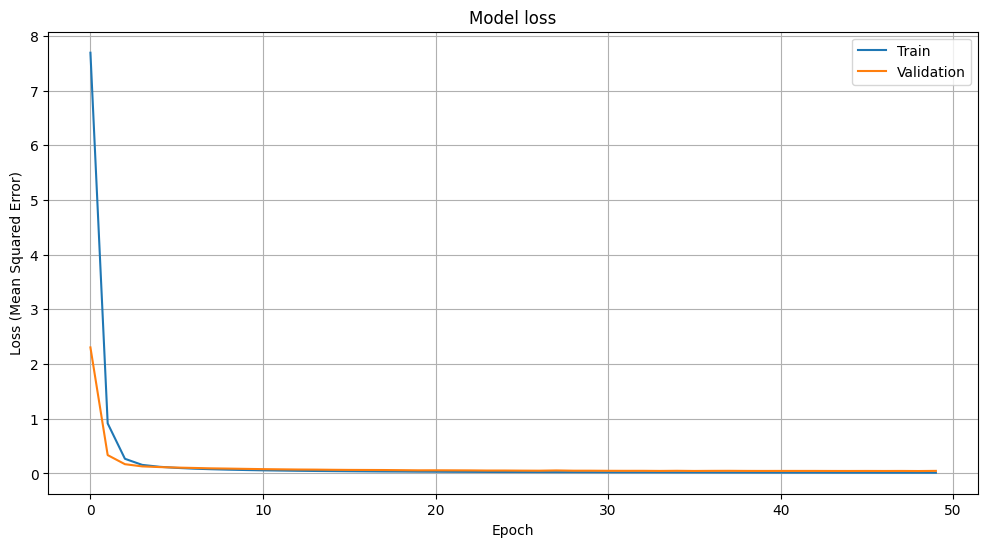

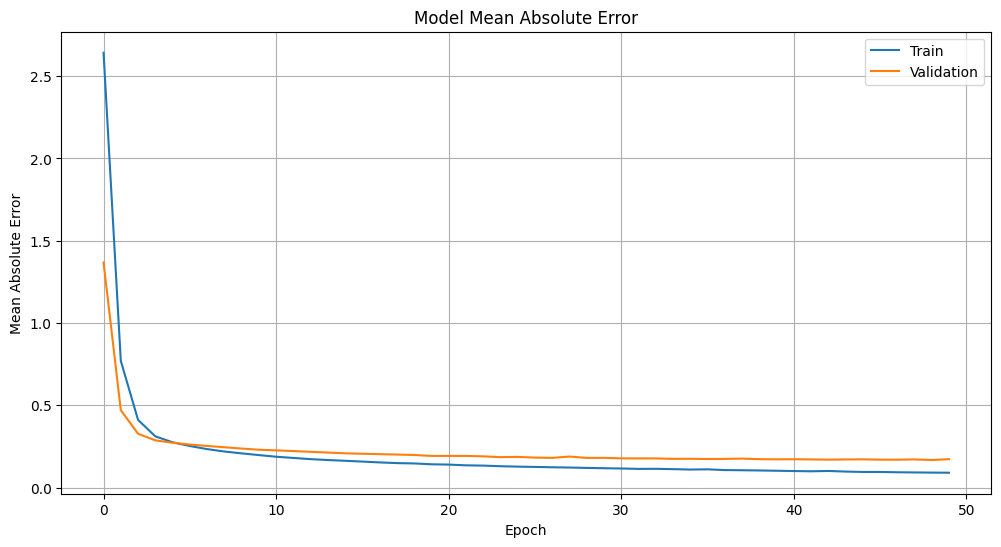

In [19]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)
plt.show()

# Plot training & validation MAE values
plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model Mean Absolute Error')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)
plt.show()

## CNN Model for Unstructured Data

Now, let's work on creating a CNN model for your unstructured dataset. We'll start with data loading and preprocessing, which will be different from the structured data.



###  Load and Preprocess CIFAR-10 Dataset

We will use the CIFAR-10 dataset, which consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images. We'll normalize the pixel values and perform one-hot encoding on the labels.

In [20]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

print(f"Original training data shape: {x_train_cifar.shape}")
print(f"Original testing data shape: {x_test_cifar.shape}")

# Normalize pixel values to be between 0 and 1
x_train_cifar = x_train_cifar.astype('float32') / 255.0
x_test_cifar = x_test_cifar.astype('float32') / 255.0

# One-hot encode the labels
y_train_cifar = to_categorical(y_train_cifar, num_classes=10)
y_test_cifar = to_categorical(y_test_cifar, num_classes=10)

print(f"Normalized training data shape: {x_train_cifar.shape}")
print(f"Normalized testing data shape: {x_test_cifar.shape}")
print(f"One-hot encoded training labels shape: {y_train_cifar.shape}")
print(f"One-hot encoded testing labels shape: {y_test_cifar.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Original training data shape: (50000, 32, 32, 3)
Original testing data shape: (10000, 32, 32, 3)
Normalized training data shape: (50000, 32, 32, 3)
Normalized testing data shape: (10000, 32, 32, 3)
One-hot encoded training labels shape: (50000, 10)
One-hot encoded testing labels shape: (10000, 10)


###  Build the CNN Model

Now, let's define a Convolutional Neural Network (CNN) for image classification using the CIFAR-10 dataset. We'll use common layers like Conv2D, MaxPooling2D, Flatten, and Dense.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Clear any old TensorFlow graph from memory to ensure a fresh model build
tf.keras.backend.clear_session()

# Define the CNN model
model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=x_train_cifar.shape[1:]),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Add dropout for regularization
    Dense(10, activation='softmax') # 10 classes for CIFAR-10
])

# Compile the model
model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

###  Train the CNN Model

Now, let's train the CNN model using the preprocessed CIFAR-10 training data. We'll use a `validation_split` to monitor performance on unseen data during training.

In [22]:
history_cnn = model_cnn.fit(x_train_cifar, y_train_cifar,
                            epochs=10, # You can increase this for better performance
                            batch_size=64,
                            validation_split=0.1,
                            verbose=1)

print("\nCNN Model training complete.")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 105ms/step - accuracy: 0.3746 - loss: 1.6977 - val_accuracy: 0.4910 - val_loss: 1.4077
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 103ms/step - accuracy: 0.5212 - loss: 1.3379 - val_accuracy: 0.5920 - val_loss: 1.1736
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 92ms/step - accuracy: 0.5838 - loss: 1.1827 - val_accuracy: 0.6406 - val_loss: 1.0101
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 93ms/step - accuracy: 0.6260 - loss: 1.0768 - val_accuracy: 0.6796 - val_loss: 0.9278
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 91ms/step - accuracy: 0.6570 - loss: 0.9849 - val_accuracy: 0.6972 - val_loss: 0.8736
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.6814 - loss: 0.9103 - val_accuracy: 0.7096 - val_loss: 0.8364
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.7030 - loss: 0.8521 - val_accuracy: 0.7154 - val_loss: 0.8330
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.7213 - loss: 0.8036 

###  Evaluate the CNN Model

After training, it's crucial to evaluate the model's performance on a separate test set to ensure it generalizes well to new, unseen data.

In [23]:
loss_cnn, accuracy_cnn = model_cnn.evaluate(x_test_cifar, y_test_cifar, verbose=0)
print(f"CNN Test Loss: {loss_cnn:.4f}")
print(f"CNN Test Accuracy: {accuracy_cnn:.4f}")

CNN Test Loss: 0.8751
CNN Test Accuracy: 0.7076


###  Visualize CNN Training History

Let's plot the training and validation accuracy and loss over epochs to understand the learning process and detect potential overfitting or underfitting.

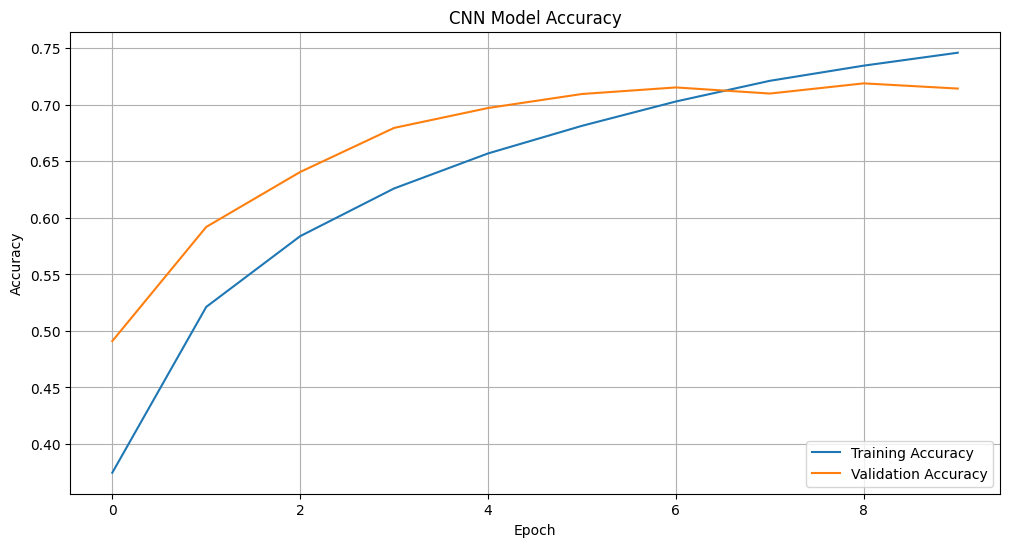

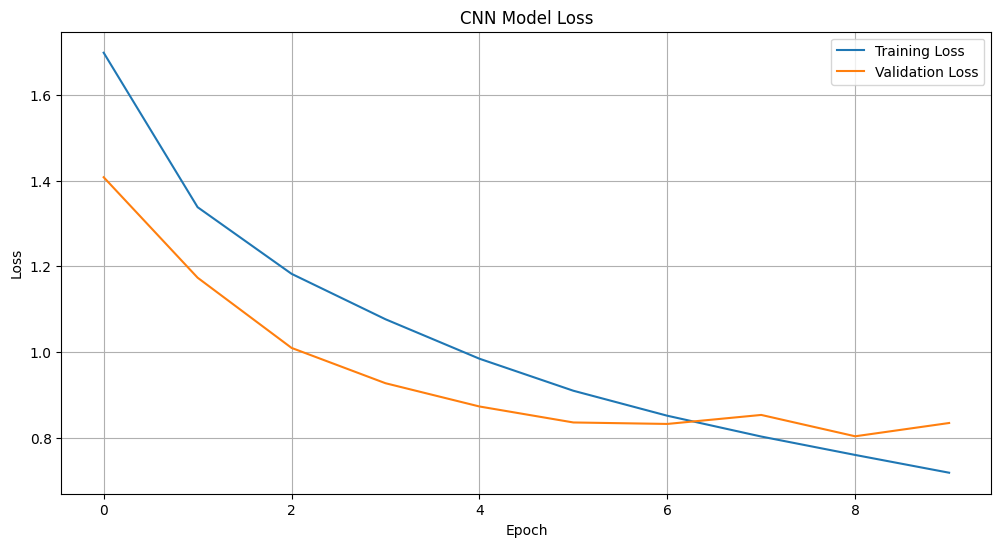

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()